<a href="https://colab.research.google.com/github/yukhaing/physical-ai-team-project-2team/blob/yuyuk-dev/YOLOsize_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!ls -la "/content/drive/MyDrive/Classifying defective boxes"

ls: '/content/drive/MyDrive/Classifying defective boxes': No such file or directory
lrw------- 1 root root 0 Jul 30 04:58 '/content/drive/MyDrive/Classifying defective boxes' -> '/content/drive/.shortcut-targets-by-id/1dJubw57Wyx5h83vyYX7wvnbYiO7bou-Y/Classifying defective boxes'


In [3]:
!ls -la "/content/drive/.shortcut-targets-by-id/1dJubw57Wyx5h83vyYX7wvnbYiO7bou-Y/Classifying defective boxes"

total 199975
-rw------- 1 root root  6331876 Jul 30 07:28 damaged_box_samples.png
drwx------ 2 root root     4096 Jul 24 05:00 dataset
-rw------- 1 root root 13067454 Jul 31 04:23 DefectiveBox_Training.ipynb
-rw------- 1 root root   384316 Jul 30 12:41 HYJ_DefectiveBox_Training.ipynb
-rw------- 1 root root 10666385 Jul 30 07:44 normal_box_samples_batch2.png
-rw------- 1 root root  6250709 Jul 30 07:42 normal_box_samples.png
drwx------ 2 root root     4096 Jul 30 04:59 runs
-rw------- 1 root root  5544453 Jul 30 04:59 yolo26n.pt
-rw------- 1 root root 87792836 Jul 30 04:59 yolov8l.pt
-rw------- 1 root root 52136884 Jul 30 07:56 yolov8m.pt
-rw------- 1 root root 22588772 Jul 30 11:33 yolov8s.pt


In [4]:
!find "/content/drive/.shortcut-targets-by-id/1dJubw57Wyx5h83vyYX7wvnbYiO7bou-Y/Classifying defective boxes/runs" -iname "results.csv"

/content/drive/.shortcut-targets-by-id/1dJubw57Wyx5h83vyYX7wvnbYiO7bou-Y/Classifying defective boxes/runs/detect/train/results.csv
/content/drive/.shortcut-targets-by-id/1dJubw57Wyx5h83vyYX7wvnbYiO7bou-Y/Classifying defective boxes/runs/yolov8m_100e/results.csv
/content/drive/.shortcut-targets-by-id/1dJubw57Wyx5h83vyYX7wvnbYiO7bou-Y/Classifying defective boxes/runs/yolov8s_100e/results.csv
/content/drive/.shortcut-targets-by-id/1dJubw57Wyx5h83vyYX7wvnbYiO7bou-Y/Classifying defective boxes/runs/yolov8l_100e_v2/results.csv


In [11]:
import pandas as pd

runs = {
    "YOLOv8s": "/content/drive/.shortcut-targets-by-id/1dJubw57Wyx5h83vyYX7wvnbYiO7bou-Y/Classifying defective boxes/runs/yolov8s_100e/results.csv",
    "YOLOv8m": "/content/drive/.shortcut-targets-by-id/1dJubw57Wyx5h83vyYX7wvnbYiO7bou-Y/Classifying defective boxes/runs/yolov8m_100e/results.csv",
    "YOLOv8l": "/content/drive/.shortcut-targets-by-id/1dJubw57Wyx5h83vyYX7wvnbYiO7bou-Y/Classifying defective boxes/runs/yolov8l_100e_v2/results.csv",
}

dfs = {}
for name, path in runs.items():
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    dfs[name] = df
    print(f"{name}: {len(df)} epochs loaded")

YOLOv8s: 100 epochs loaded
YOLOv8m: 100 epochs loaded
YOLOv8l: 100 epochs loaded


In [12]:
summary = []
for name, df in dfs.items():
    last_row = df.iloc[-1]
    summary.append({
        'Model': name,
        'mAP50': round(last_row['metrics/mAP50(B)'], 4),
        'mAP50-95': round(last_row['metrics/mAP50-95(B)'], 4),
        'Precision': round(last_row['metrics/precision(B)'], 4),
        'Recall': round(last_row['metrics/recall(B)'], 4),
    })

summary_df = pd.DataFrame(summary)
print(summary_df)

     Model   mAP50  mAP50-95  Precision  Recall
0  YOLOv8s  0.7473    0.7311     0.6638  0.8074
1  YOLOv8m  0.7734    0.7630     0.6512  0.8555
2  YOLOv8l  0.8430    0.8396     0.7018  0.8145


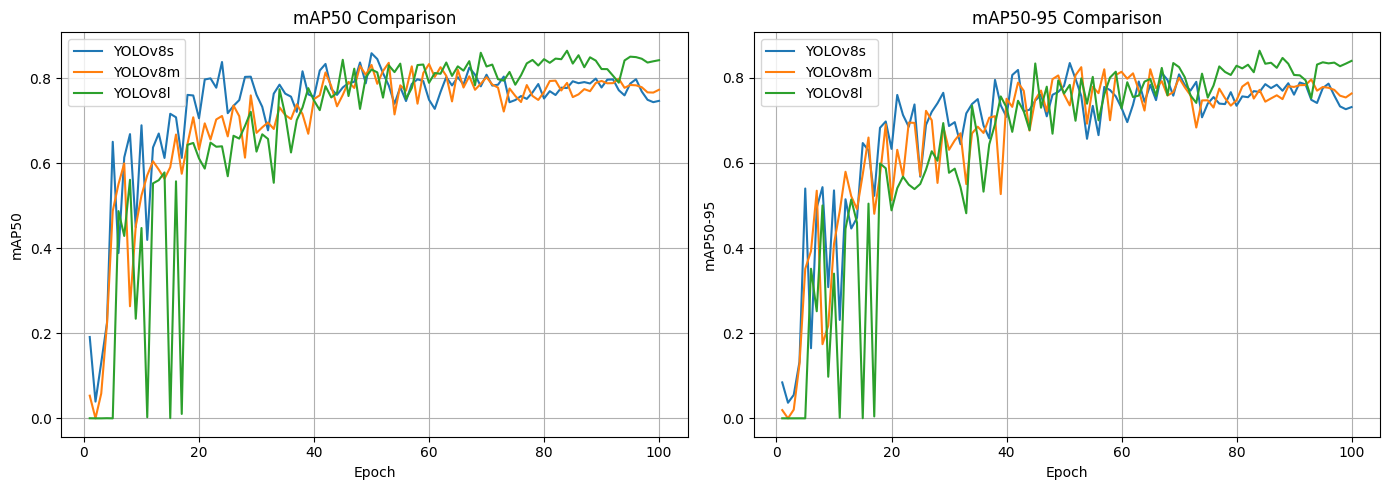

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metric1 = "metrics/mAP50(B)"
metric2 = "metrics/mAP50-95(B)"

for name, df in dfs.items():
    axes[0].plot(df["epoch"], df[metric1], label=name)
    axes[1].plot(df["epoch"], df[metric2], label=name)

axes[0].set_title("mAP50 Comparison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("mAP50")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("mAP50-95 Comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("mAP50-95")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig("model_size_comparison.png")
plt.show()

In [13]:
summary_df.to_csv('model_size_comparison.csv', index=False)

from google.colab import files
files.download('model_size_comparison.csv')
files.download('model_size_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>